# BLA Frequency Domain Absolute Power — All Times  
## Centered to a global across-trial mean baseline

This notebook only does the **frequency-domain absolute power, all-times** analysis.

### What is different here?
In your earlier baseline-centered version, each trial was centered to its own **pre-stimulus** baseline window (`-500 ms to -50 ms`).

In **this** notebook, the baseline is defined differently:

- First compute the **absolute band power** for each trial using the **full epoch** ("all times")
- Then, for each **subject** and each **frequency band**, compute the **average of those trial powers across all trials**
- That one average value becomes the **global baseline** for that subject and band
- Then subtract that same baseline from every trial in that subject and band

So the centering is now:

\[
\text{centered power}_{trial,band} = \text{raw power}_{trial,band} - \overline{\text{raw power}}_{all\ trials,band}
\]

This means:
- `0` = equal to that subject's average full-epoch power for that band
- `> 0` = above that subject's across-trial average
- `< 0` = below that subject's across-trial average


In [1]:

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [2]:

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials


In [3]:

# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched BLA data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


In [4]:

# These dictionaries will store the grand-average centered power across subjects
# for each band, plus the SEM at each trial index.
grand_power = {}
grand_sem = {}

# Loop through one frequency band at a time.
for band in bands:

    # This list will hold one vector per subject.
    # Each vector is that subject's centered power across trials for this band.
    band_trials = []

    # Go through all successfully processed subjects.
    for subject_id in processed_subjects:

        # Pull out that subject's centered trial x band table.
        power_pivot = all_power_pivots_centered[subject_id]

        # Only continue if this band is present in the table.
        if band in power_pivot.columns:

            # Extract the one column for this band.
            #
            # reset_index(drop=True) makes the row labels run 0, 1, 2, ...
            # This matters when we concatenate subjects side by side:
            # we want alignment by trial position, not by any leftover index labels.
            band_trials.append(power_pivot[band].reset_index(drop=True))

    # Only compute the grand average if at least one subject contributed data.
    if band_trials:

        # Combine all subject vectors side by side into one table.
        #
        # Rows = trial index
        # Columns = subject
        band_df = pd.concat(band_trials, axis=1)

        # Compute the grand mean across subjects for each trial index.
        #
        # mean(axis=1) means:
        # average ACROSS columns, so across subjects, row by row.
        grand_power[band] = band_df.mean(axis=1)

        # Compute the standard error of the mean (SEM) across subjects.
        #
        # std(axis=1) gives the standard deviation across subjects at each trial.
        # Dividing by sqrt(N) converts that to SEM.
        grand_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


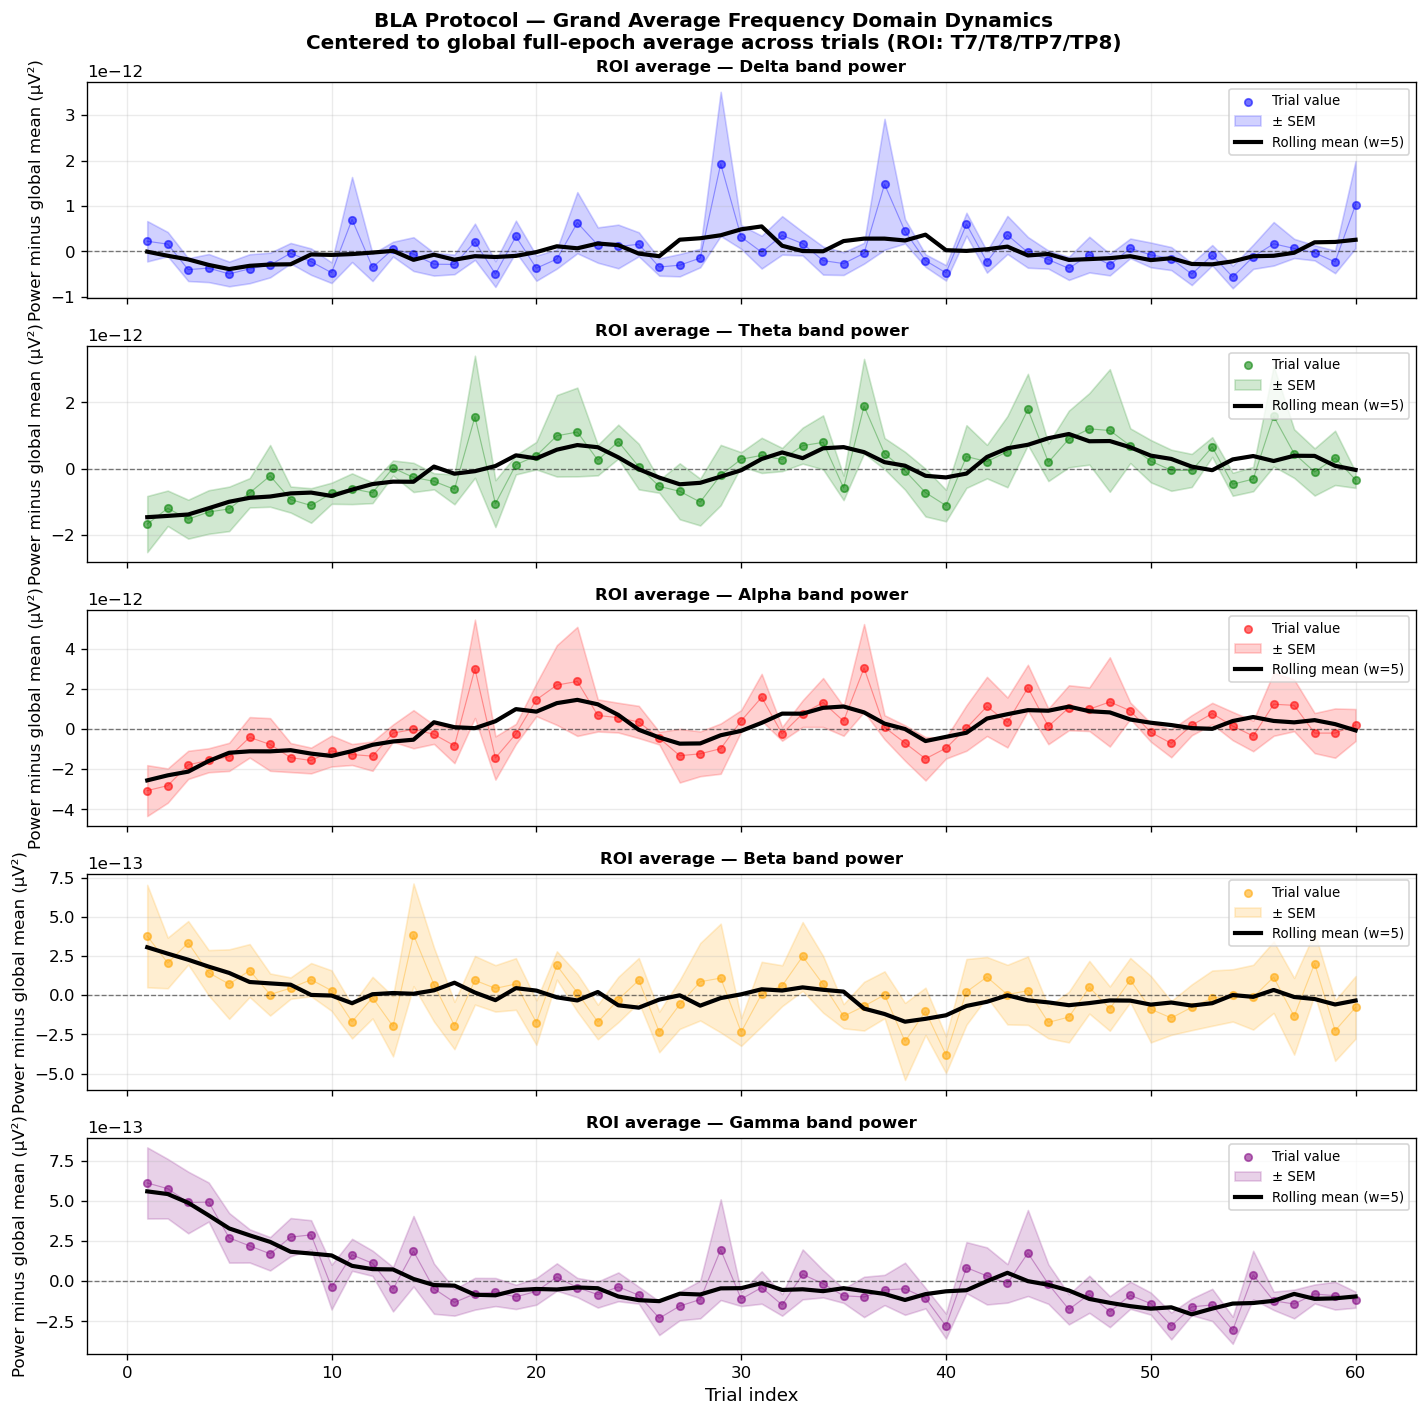

Figure saved: frequency_dynamics_BLA_global_mean_centered.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Values above 0 are above the subject's across-trial mean for that band.
Values below 0 are below the subject's across-trial mean for that band.


In [5]:

# Create one subplot per band so each frequency range gets its own panel.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

# Loop over each band and its matching plot color.
for i, (band, color) in enumerate(zip(bands, colors)):

    # Select the subplot for this band.
    ax = axes[i]

    # Only plot if data exists for this band.
    if band in grand_power:

        # Pull the grand-average centered values into a NumPy array for plotting.
        values = grand_power[band].values

        # Pull the SEM values for the same trial positions.
        errors = grand_sem[band].values

        # Build the x-axis as trial numbers starting at 1 instead of 0.
        trial_idx = np.arange(1, len(values) + 1)

        # Plot the trial-by-trial grand mean as scatter points.
        # Each point is one trial index after averaging across subjects.
        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        # Draw a faint thin line through the same points.
        # This does not add new data; it just makes the sequence easier to follow visually.
        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        # Fill between mean - SEM and mean + SEM.
        # This gives a visual sense of uncertainty around the grand mean.
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Compute a rolling mean for a smoother trend line.
        #
        # center=True centers the smoothing window on each trial.
        # min_periods=1 prevents NaNs at the edges by allowing smaller edge windows.
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        # Plot the rolling mean as a thicker black trend line.
        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    # Label the y-axis.
    # These values are no longer "power minus pre-stimulus baseline."
    # They are "power minus subject's global across-trial mean for that band."
    ax.set_ylabel('Power minus global mean (µV²)', fontsize=10)

    # Give each subplot a descriptive title.
    ax.set_title(
        f'ROI average — {band.capitalize()} band power',
        fontsize=10,
        fontweight='bold'
    )

    # Add a horizontal zero line.
    # Because of the centering, 0 means "equal to the subject-level global baseline."
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Show the legend.
    ax.legend(loc='upper right', fontsize=8)

    # Add a light grid so trial-to-trial changes are easier to see.
    ax.grid(True, alpha=0.25)

# Label the shared x-axis on the bottom subplot only.
axes[-1].set_xlabel('Trial index', fontsize=11)

# Add one overall figure title.
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics\n'
    'Centered to global full-epoch average across trials (ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

# Tight layout reduces overlap between titles, axes, and labels.
fig.tight_layout()

# Save the figure to disk so you can reuse it outside the notebook.
plt.savefig('frequency_dynamics_BLA_global_mean_centered.png', bbox_inches='tight', dpi=150)

# Display the figure in the notebook.
plt.show()

print("Figure saved: frequency_dynamics_BLA_global_mean_centered.png")
print(f"Analysis completed for subjects: {processed_subjects}")
print("Values above 0 are above the subject's across-trial mean for that band.")
print("Values below 0 are below the subject's across-trial mean for that band.")


In [11]:

# This optional cell lets you inspect the actual global baseline values
# that were subtracted for one example subject.

# Pick the first successfully processed subject.
example_subject = processed_subjects[0]

print(f"Example subject: {example_subject}")
print("One-row table of global band-wise baseline values:")

all_global_baseline_pivots[example_subject]


Example subject: 2
One-row table of global band-wise baseline values:


,delta,theta,alpha,beta,gamma
0,3.983466e-12,3.752882e-12,2.394402e-12,3.548100e-12,1.754167e-12
